In [2]:
import sys
from pathlib import Path
ROOT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import config
import pandas as pd
import numpy as np

df_process = pd.read_csv(config.TRAIN_PATH).copy()
print(df_process.shape)

(1460, 81)


In [3]:
# Изучим данные и построим графики для знакомства с признаками

df_process.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [4]:
df_process.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
df_process.duplicated().sum()

# В таблице нет дубликатов

np.int64(0)

In [8]:
constant_cols = df_process.columns[df_process.nunique() <= 1]
print(constant_cols)

# В таблице нет константных признаков

Index([], dtype='object')


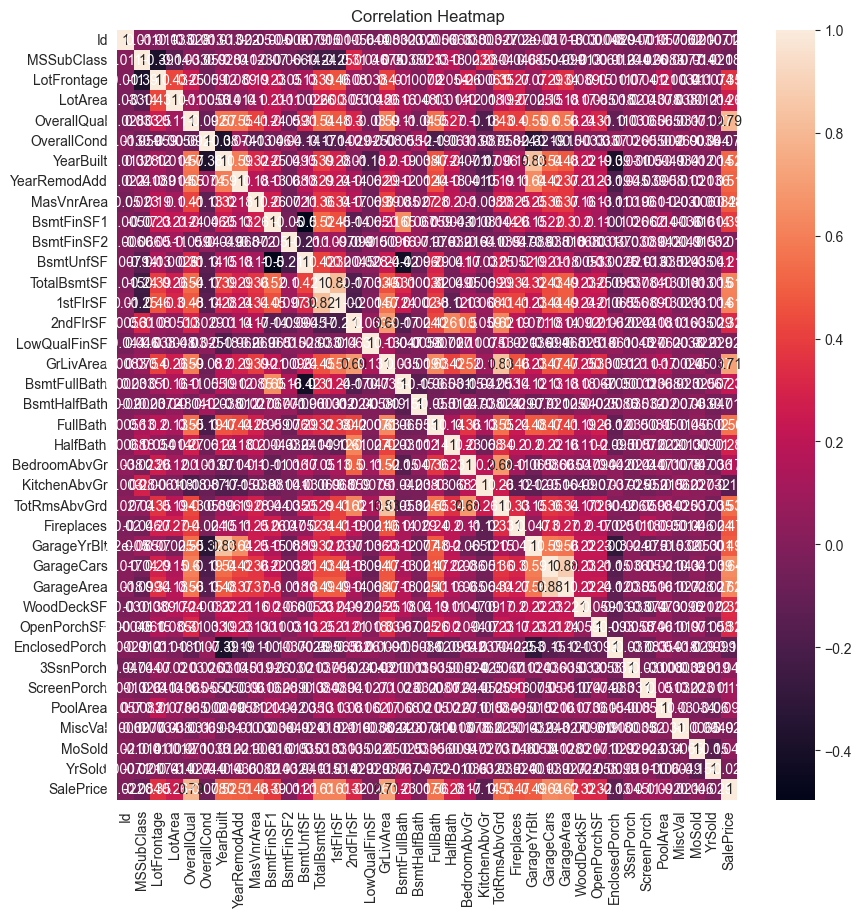

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_process.corr(numeric_only=True)

plt.figure(figsize = (10,10))
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [12]:
df_process.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [29]:
df_process['GarageCond'].unique()

array(['TA', 'Fa', nan, 'Gd', 'Po', 'Ex'], dtype=object)

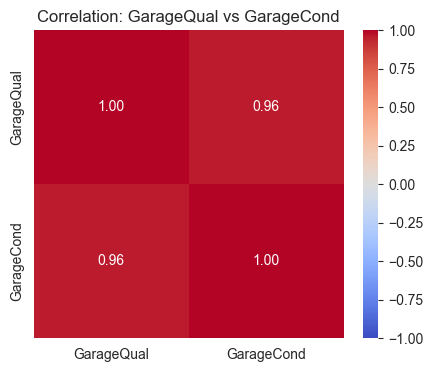

In [30]:
garage_qual_map = {
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}

df_process[['GarageQual', 'GarageCond']] = (
    df_process[['GarageQual', 'GarageCond']]
    .apply(lambda col: col.map(garage_qual_map).fillna(0).astype(int))
)
corr = df_process[['GarageQual', 'GarageCond']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            vmin=-1, vmax=1)
plt.title('Correlation: GarageQual vs GarageCond')
plt.show()

In [31]:
print(df_process[['GarageQual', 'GarageCond']].head(20))
print(df_process[['GarageQual', 'GarageCond']].nunique())
print(df_process[['GarageQual', 'GarageCond']].corr())

    GarageQual  GarageCond
0            3           3
1            3           3
2            3           3
3            3           3
4            3           3
5            3           3
6            3           3
7            3           3
8            2           3
9            4           3
10           3           3
11           3           3
12           3           3
13           3           3
14           3           3
15           3           3
16           3           3
17           3           3
18           3           3
19           3           3
GarageQual    6
GarageCond    6
dtype: int64
            GarageQual  GarageCond
GarageQual    1.000000    0.959172
GarageCond    0.959172    1.000000


In [44]:
df_process['Condition1'].unique()

array(['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA',
       'RRNe'], dtype=object)

In [45]:

df_process['Condition2'].unique()

array(['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe'],
      dtype=object)

In [48]:
same_first = (df_process['Condition1'] == df_process['Condition2']).mean()

print(f"Совпадают: {same_first:.2%}")

Совпадают: 86.64%


In [64]:

df_process['Exterior2nd'].unique()


array(['VinylSd', 'MetalSd', 'Wd Shng', 'HdBoard', 'Plywood', 'Wd Sdng',
       'CmentBd', 'BrkFace', 'Stucco', 'AsbShng', 'Brk Cmn', 'ImStucc',
       'AsphShn', 'Stone', 'Other', 'CBlock'], dtype=object)

In [65]:
same_sec = (df_process['Exterior1st'] == df_process['Exterior2nd']).mean()

print(f"Совпадают: {same_sec:.2%}")

Совпадают: 85.27%


In [3]:
df_process['TotalBsmtSF'].unique()

array([ 856, 1262,  920,  756, 1145,  796, 1686, 1107,  952,  991, 1040,
       1175,  912, 1494, 1253,  832, 1004,    0, 1114, 1029, 1158,  637,
       1777, 1060, 1566,  900, 1704, 1484,  520,  649, 1228, 1234, 1398,
       1561, 1117, 1097, 1297, 1057, 1088, 1350,  840,  938, 1150, 1752,
       1434, 1656,  736,  955,  794,  816, 1842,  384, 1425,  970,  860,
       1410,  780,  530, 1370,  576, 1143, 1947, 1453,  747, 1304, 2223,
        845, 1086,  462,  672, 1768,  440,  896, 1237, 1563, 1065, 1288,
        684,  612, 1013,  990, 1235,  876, 1214,  824,  680, 1588,  960,
        458,  950, 1610,  741, 1226, 1053,  641,  789,  793, 1844,  994,
       1264, 1809, 1028,  729, 1092, 1125, 1673,  728,  732, 1080, 1199,
       1362, 1078,  660, 1008,  924,  992, 1063, 1267, 1461, 1907,  928,
        864, 1734,  910, 1490, 1728,  715,  884,  969, 1710,  825, 1602,
       1200,  572,  774, 1392, 1232, 1572, 1541,  882, 1149,  644, 1617,
       1582,  720, 1064, 1606, 1202, 1151, 1052, 22